#  Problem statement: Crop Yield Prediction Using Machine Learning Techniques :
The solution involves developing and comparing multiple supervised regression models, including Linear Regression, Decision Tree Regression, and Random Forest Regression, to capture linear and nonlinear relationships among agricultural and environmental features for accurate crop yield prediction.

# Data Separation :

In [1]:
import pandas as pd  # For data handling
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns  # For advanced visualizations

from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler  # For encoding & scaling
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor  # ML model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  # Evaluation metrics

In [2]:
# Load Dataset
df=pd.read_csv('crop_yield.csv') # Load dataset
df.head()# Display first 5 rows

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [3]:
df.shape  # Check dataset size
df.isnull().sum()  # Check missing values

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [4]:
df.size

196890

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [7]:
# Separate Features and Target
x = df.drop(['Yield', 'Production'], axis=1)
y = df['Yield']
x

,Crop,Crop_Year,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide
0,Arecanut,1997,Whole Year,Assam,73814.0,2051.4,7024878.38,22882.34
1,Arhar/Tur,1997,Kharif,Assam,6637.0,2051.4,631643.29,2057.47
2,Castor seed,1997,Kharif,Assam,796.0,2051.4,75755.32,246.76
3,Coconut,1997,Whole Year,Assam,19656.0,2051.4,1870661.52,6093.36
4,Cotton(lint),1997,Kharif,Assam,1739.0,2051.4,165500.63,539.09
...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,1498.0,395200.00,1160.00
19685,Wheat,1998,Rabi,Nagaland,1000.0,1498.0,98800.00,290.00
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,1356.2,29586735.11,96373.73
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,1356.2,26242746.82,85481.26


In [8]:
total=df.isnull().sum()
percent=round((df.isnull().sum()*100/len(df)),2)
total_missing=pd.concat([total,percent],axis=1,
                       keys=['total missing','Percent of missing'])
total_missing.sort_values(by='total missing',ascending=False)

,total missing,Percent of missing
Crop,0,0.0
Crop_Year,0,0.0
Season,0,0.0
State,0,0.0
Area,0,0.0
Production,0,0.0
Annual_Rainfall,0,0.0
Fertilizer,0,0.0
Pesticide,0,0.0
Yield,0,0.0


In [9]:
print(df.columns)

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')


In [10]:
categorical_cols = ["Crop", "Season", "State"]  # Categorical columns list
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")  # Create encoder
encoder

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [11]:
encoded = encoder.fit_transform(x[categorical_cols])  # Fit & transform categorical data
encoded

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(19689, 88))

In [12]:
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))  # Convert to DataFrame
x_encode = pd.concat([x.drop(categorical_cols, axis=1).reset_index(drop=True),
                     encoded_df], axis=1)  # Combine numerical + encoded columns

In [13]:
#scaling
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(x_encode)# Scale features
x_scaled


array([[0.00000000e+00, 1.45279002e-03, 2.79953290e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.30618938e-04, 2.79953290e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.56569525e-05, 2.79953290e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 6.11875868e-03, 1.68746201e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 5.42719572e-03, 1.68746201e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 4.71073515e-03, 1.68746201e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(19689, 93))

In [14]:
#  Train-Test Split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.20,random_state=40)
print(f'x_train:{x_train.shape}')
print(f'x_test:{x_test.shape}')
print(f'y_train:{y_train.shape}')
print(f'y_test:{y_test.shape}')


x_train:(15751, 93)
x_test:(3938, 93)
y_train:(15751,)
y_test:(3938,)


# Model :

In [15]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

y_pred_lr = lr_model.predict(x_test)

print("Linear Regression Results")
print("R2 Score:", round(r2_score(y_test, y_pred_lr)*100, 2), "%")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print()

Linear Regression Results
R2 Score: 85.91 %
MAE: 58.34859535884368
MSE: 88613.81951432204



In [16]:
# Decision Tree Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

print("Decision Tree Results")
print("R2 Score:", round(r2_score(y_test, y_pred_dt)*100, 2), "%")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print()


Decision Tree Results
R2 Score: 95.76 %
MAE: 10.691726462057643
MSE: 26646.83739982029



In [17]:
# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
rf_model.fit(x_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred_rf = rf_model.predict(x_test)
print("Random Forest Results")
print("R2 Score:", round(r2_score(y_test, y_pred_rf)*100, 2), "%")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest Results
R2 Score: 97.18 %
MAE: 9.189022096032275
MSE: 17752.02387595712


In [20]:
#Prediction of yield
new_input = x_encode.iloc[[2]]   # or manually create 94 feature list
scaling = scaler.transform(new_input)
prediction =rf_model.predict(scaling)
print("Predicted Yield:", prediction[0])


Predicted Yield: 0.4430337897750004


# Model Comparison :

In [21]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

results


,Model,R2 Score
0,Linear Regression,0.859056
1,Decision Tree,0.957617
2,Random Forest,0.971765


# Yield Distribution Graph :

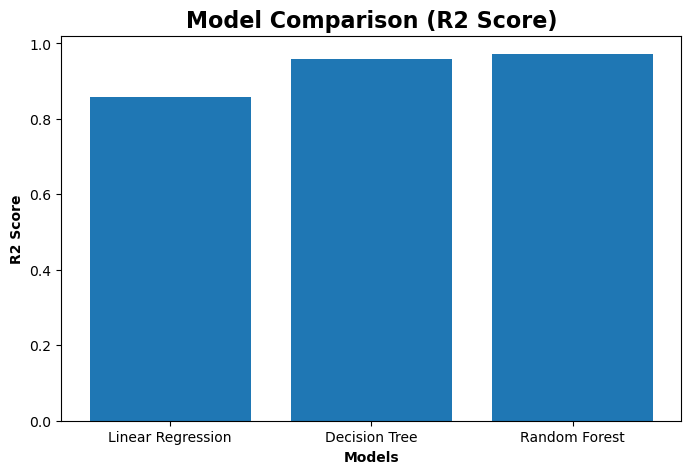

In [22]:
# Create comparison bar chart
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison (R2 Score)", fontsize=16, fontweight='bold')
plt.xlabel("Models", fontweight='bold')
plt.ylabel("R2 Score", fontweight='bold')
plt.show()


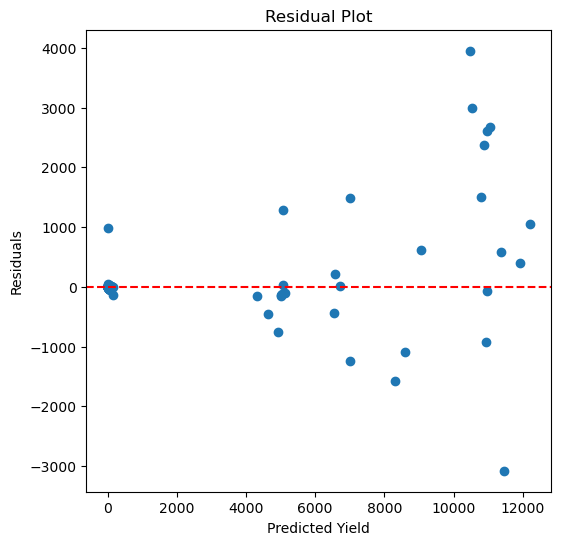

In [23]:
# Residual Plot
residuals = y_test - y_pred_rf
plt.figure(figsize=(6,6))
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


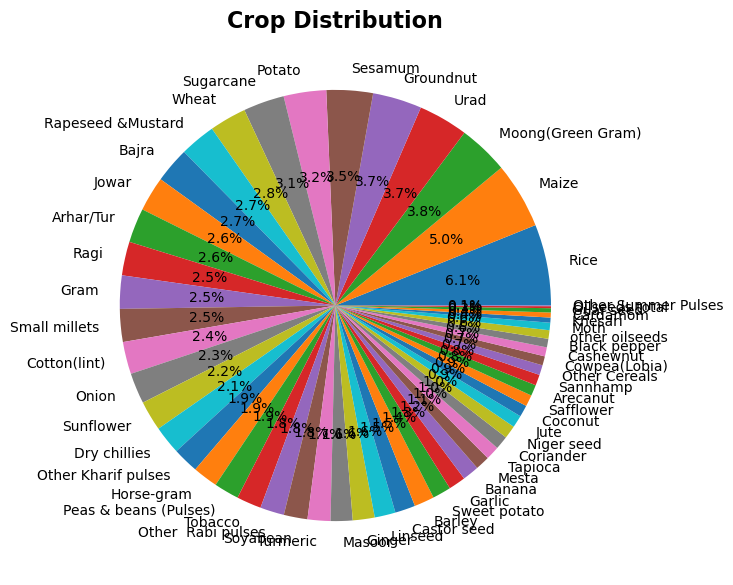

In [24]:
#Crop Distribution
plt.figure(figsize=(7,7))
crop_counts = df["Crop"].value_counts()
plt.pie(crop_counts,
        labels=crop_counts.index,
        autopct='%1.1f%%')
plt.title("Crop Distribution", fontsize=16, fontweight='bold')
plt.show()

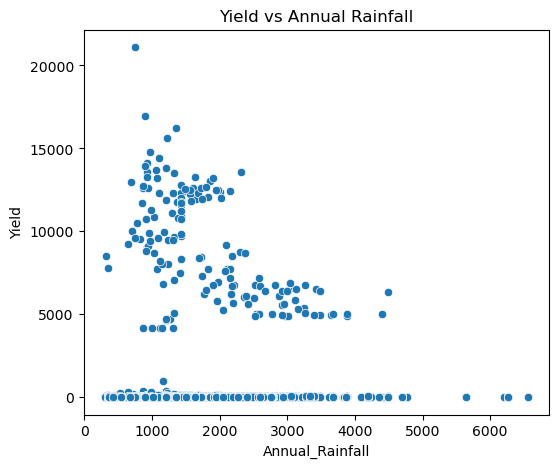

In [25]:
#Yield vs Annual Rainfall
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Annual_Rainfall"], y=df["Yield"])
plt.title("Yield vs Annual Rainfall")
plt.show()

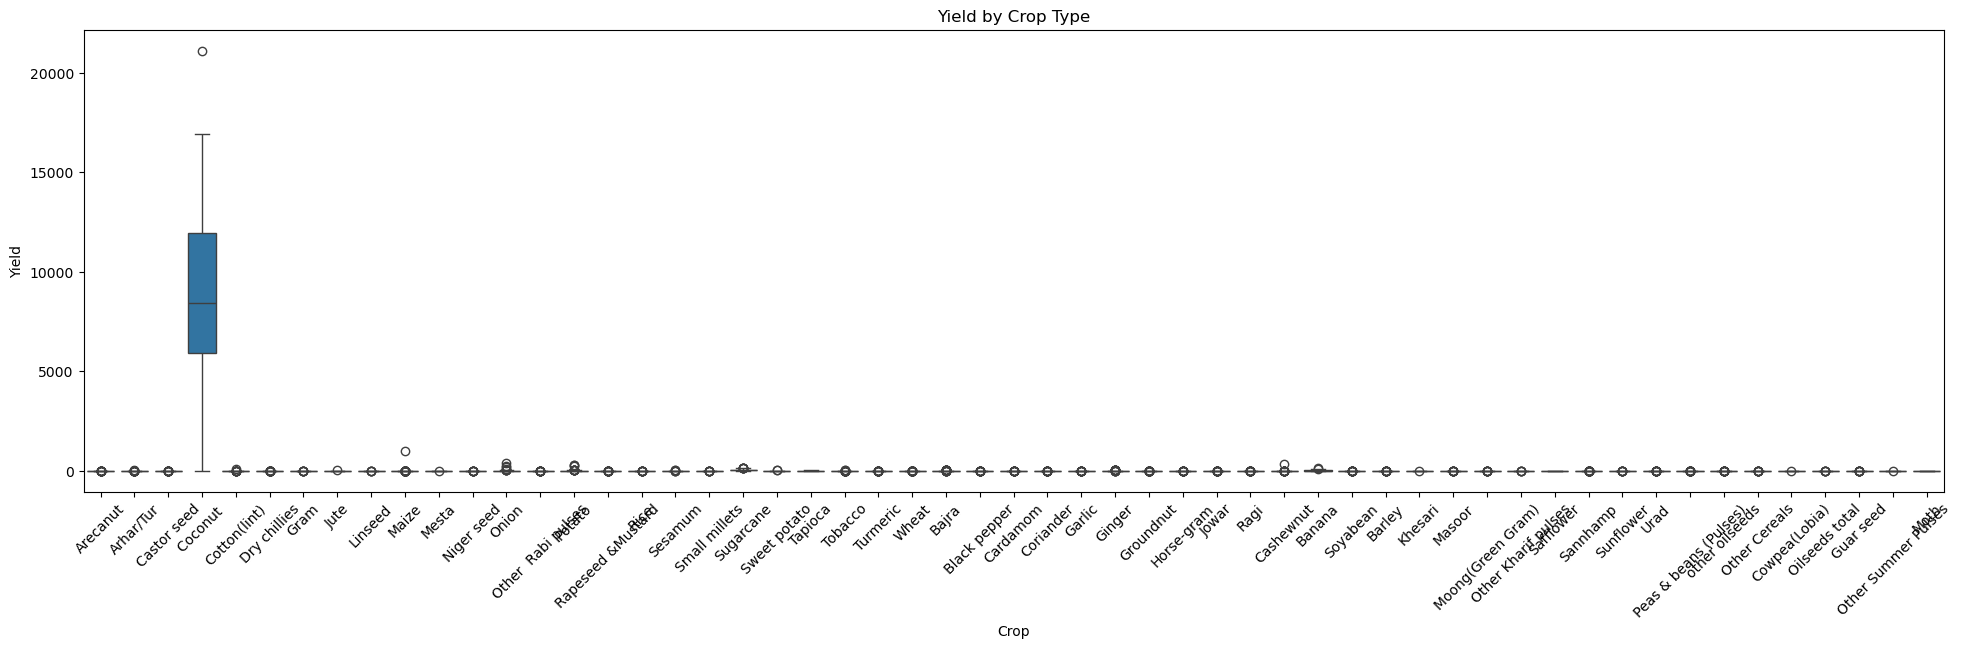

In [26]:
#Yield by Crop Type
plt.figure(figsize=(24,6))
sns.boxplot(x='Crop', y='Yield', data=df)
plt.xticks(rotation=45)
plt.title("Yield by Crop Type")
plt.show()

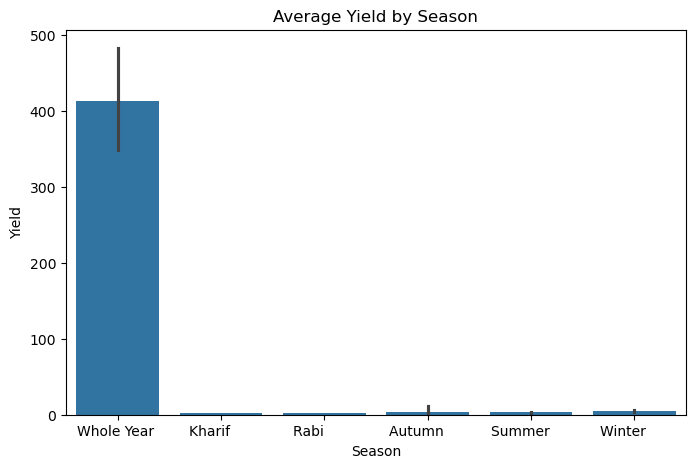

In [27]:
#Yield by Season
plt.figure(figsize=(8,5))
sns.barplot(x='Season', y='Yield', data=df)
plt.title("Average Yield by Season")
plt.show()

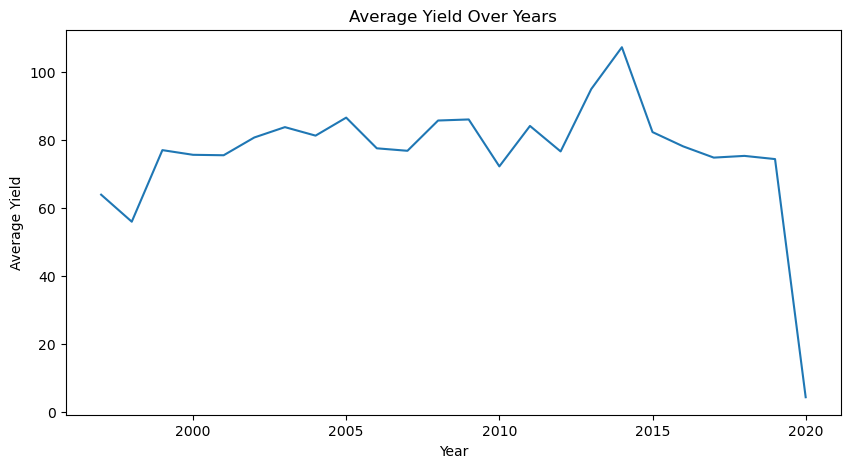

In [28]:
#Average Yield Over Years
yearly_avg = df.groupby("Crop_Year")["Yield"].mean()
plt.figure(figsize=(10,5))
yearly_avg.plot()
plt.title("Average Yield Over Years")
plt.xlabel("Year")
plt.ylabel("Average Yield")
plt.show()

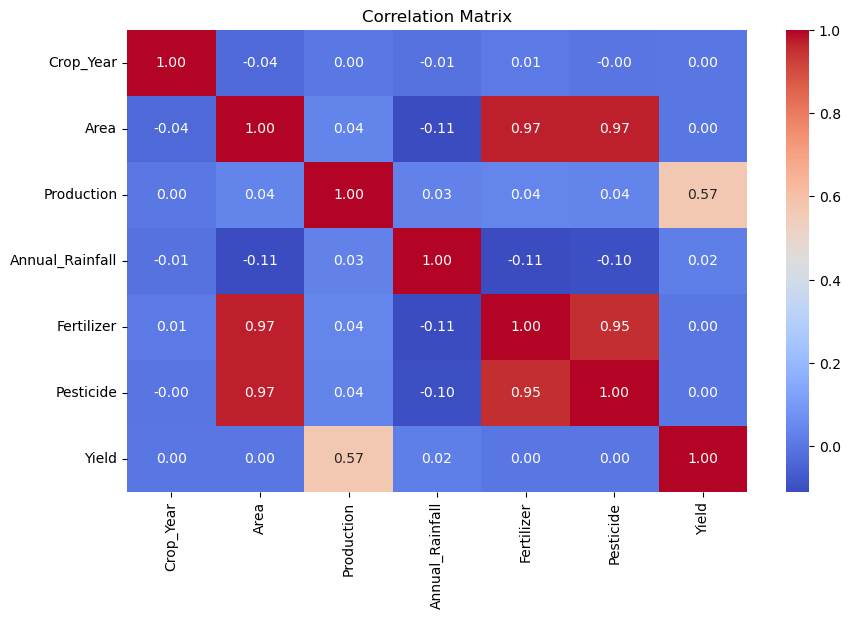

In [29]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

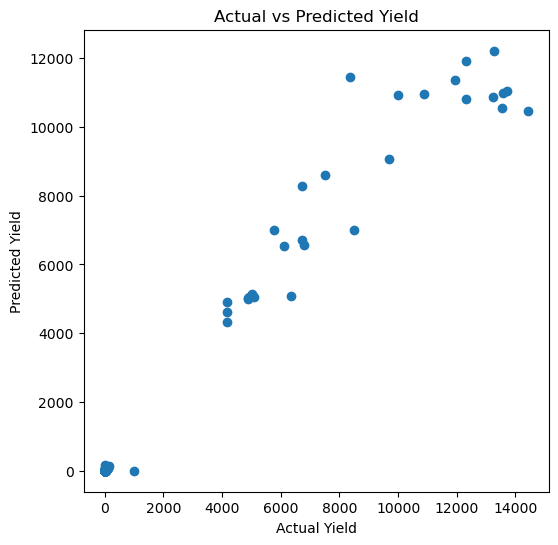

In [30]:
#Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

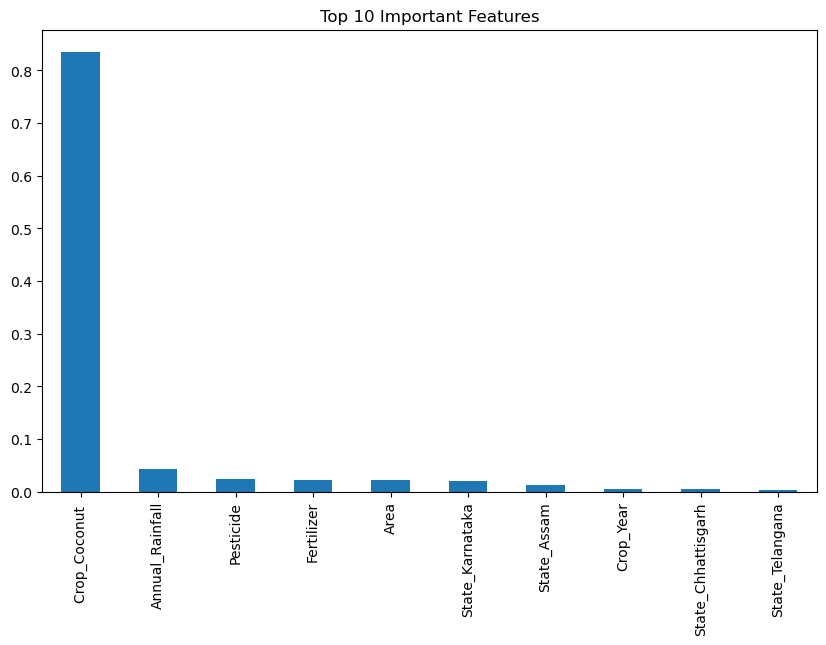

In [31]:
#feature importance
importances = rf_model.feature_importances_
feature_names = x_encode.columns
feat_imp = pd.Series(importances, index=feature_names)
plt.figure(figsize=(10,6))
feat_imp.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()


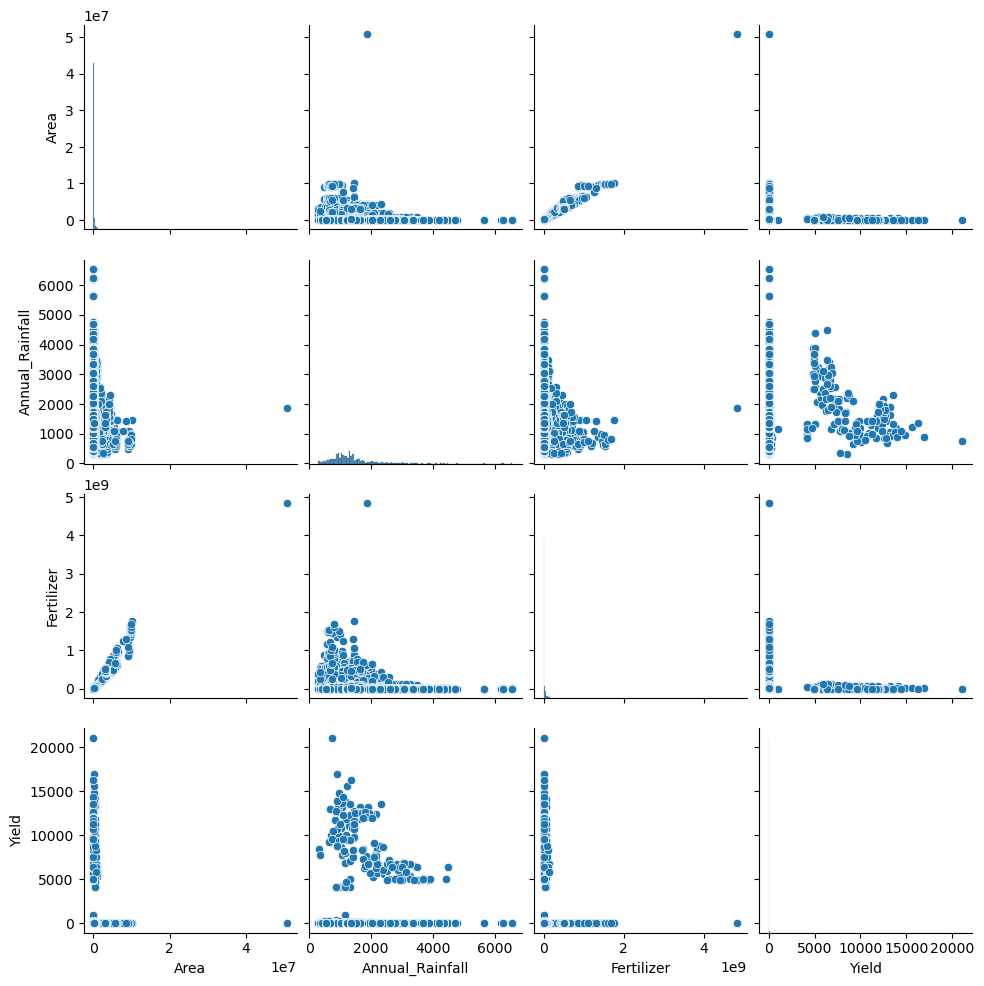

In [32]:
sns.pairplot(df[["Area", "Annual_Rainfall", "Fertilizer", "Yield"]])
plt.show()